# Transfer Probe Layer Example

Select a protein-level probing dataset, generate one pooled embedding layer, and evaluate it with `TransferProbe`. The transfer probe predicts from nearby training embeddings instead of fitting a Torch model.


In [65]:
from __future__ import annotations

from dataclasses import replace
import gc
import math
import os
from pathlib import Path
import sys
from typing import Sequence

NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / "CBBIO").exists() else NOTEBOOK_DIR.parent
if not (REPO_ROOT / "CBBIO").exists():
    raise RuntimeError("Could not find the CBBIO package directory. Start Jupyter from the repo root or notebooks/.")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

os.environ.setdefault("MPLCONFIGDIR", str(Path("/tmp") / "matplotlib"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm

from CBBIO import (
    GenerationInput,
    Generator,
    PredictionSpec,
    ProteinDataset,
    Task,
    TransferProbe,
    collect_generation_results,
    filter_redundant_to_test_mmseqs,
    get_dataset_catalog_entry,
    list_dataset_catalog,
    load_dataset,
    load_peer_dataset,
    run_task_on_layer,
)
from CBBIO.embeddings import EmbeddingDependencyError, EmbeddingInputError

pd.set_option("display.max_colwidth", 120)

globals().pop("embeddings", None)
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()


## Configuration

Start with a small protein-level EC task. `TransferProbe` only supports protein-level tasks, so the dataset-resolution cell rejects residue datasets before any embeddings are generated.


In [66]:
DATA_ROOT = Path("notebooks/data/probing") if Path("notebooks/data/probing").exists() else Path("data/probing")

DATASET_ID = "go:go_mf_full"
DOWNLOAD_DATA = True
PEER_SPLIT: str | Sequence[str] | None = None

# Keep these low while iterating. Set to None for full splits.
MAX_TRAIN_EXAMPLES: int | None = 100000
MAX_VAL_EXAMPLES: int | None = 15000
MAX_TEST_EXAMPLES: int | None = 15000
MAX_SEQUENCE_LENGTH: int | None = 1024

# Optional MMseqs2 train/val-to-test sequence-similarity filtering.
FILTER_REDUNDANT_TO_TEST = True
REDUNDANCY_IDENTITY_CUTOFF = 30.0
REDUNDANCY_MIN_COVERAGE = 0.8
REDUNDANCY_THREADS: int | None = None

# Small default model for a quick transfer-probe smoke run.
MODEL_CLASS = "esmc"
MODEL_NAME: str | None = "esmc_300m"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SELECTED_LAYER = 18
POOLER = "mean"
EMBEDDING_BATCH_SIZE = 16
MAX_BATCH_TOKENS: int | None = 32768
LENGTH_SORT_WINDOW: int | None = 256

# TransferProbe controls.
TRANSFER_DISTANCE = "cosine"
TRANSFER_NEIGHBOR_SELECTION = "knn"
TRANSFER_K = 25
TRANSFER_SCORING = "weighted_voting"
TRANSFER_THRESHOLD: float | None = 0.25
TRANSFER_DISTANCE_CUTOFF: float | None = None
TRANSFER_RETURN_NEIGHBORS = True

METRIC: str | None = None
MAX_CPU_THREADS: int | None = min(4, os.cpu_count() or 1)
MAX_TORCH_INTEROP_THREADS: int | None = 4
DISABLE_TOKENIZERS_PARALLELISM = False


## Runtime Limits


In [67]:
def apply_runtime_resource_limits(
    *,
    max_cpu_threads: int | None,
    max_torch_interop_threads: int | None,
    disable_tokenizers_parallelism: bool,
) -> None:
    thread_env = {
        "OMP_NUM_THREADS": max_cpu_threads,
        "OPENBLAS_NUM_THREADS": max_cpu_threads,
        "MKL_NUM_THREADS": max_cpu_threads,
        "VECLIB_MAXIMUM_THREADS": max_cpu_threads,
        "NUMEXPR_NUM_THREADS": max_cpu_threads,
    }
    for key, value in thread_env.items():
        if value is not None:
            os.environ[key] = str(int(value))
    if disable_tokenizers_parallelism:
        os.environ["TOKENIZERS_PARALLELISM"] = "false"
    if max_cpu_threads is not None:
        torch.set_num_threads(int(max_cpu_threads))
    if max_torch_interop_threads is not None:
        try:
            torch.set_num_interop_threads(int(max_torch_interop_threads))
        except RuntimeError:
            pass


apply_runtime_resource_limits(
    max_cpu_threads=MAX_CPU_THREADS,
    max_torch_interop_threads=MAX_TORCH_INTEROP_THREADS,
    disable_tokenizers_parallelism=DISABLE_TOKENIZERS_PARALLELISM,
)


## Select Dataset


In [68]:
protein_ready = [entry for entry in list_dataset_catalog(status="ready") if entry.level == "protein"]
pd.DataFrame([entry.__dict__ for entry in protein_ready]).loc[
    :, ["id", "display_name", "collection", "objective", "target", "preferred_metric"]
].head(20)


,id,display_name,collection,objective,target,preferred_metric
0,peer:gb1,GB1 fitness prediction,peer,regression,target,spearmanr
1,peer:aav,AAV fitness prediction,peer,regression,target,spearmanr
2,peer:thermostability,Thermostability prediction,peer,regression,target,spearmanr
3,peer:fluorescence,Fluorescence prediction,peer,regression,log_fluorescence,spearmanr
4,peer:stability,Stability prediction,peer,regression,stability_score,spearmanr
5,peer:beta_lactamase,Beta-lactamase activity prediction,peer,regression,scaled_effect1,spearmanr
6,peer:solubility,Solubility prediction,peer,binary,solubility,accuracy
7,peer:subcellular_localization,Subcellular localization prediction,peer,multiclass,localization,accuracy
8,peer:binary_localization,Binary localization prediction,peer,binary,localization,accuracy
9,peer:fold,Fold classification,peer,multiclass,fold_label,accuracy


In [69]:
dataset_entry = get_dataset_catalog_entry(DATASET_ID)
if dataset_entry.status not in {"ready", "adapter"}:
    raise EmbeddingInputError(f"Dataset {dataset_entry.id!r} is not loadable yet: status={dataset_entry.status!r}.")
if dataset_entry.level != "protein":
    raise EmbeddingInputError("TransferProbe supports protein-level tasks only. Choose a protein-level dataset.")

pd.DataFrame([dataset_entry.__dict__]).T.rename(columns={0: "value"})


,value
id,go:go_mf_full
name,go_mf_full
display_name,GO molecular function (full)
collection,go
source,Gene Ontology annotations
category,function_prediction
task_class,function
preferred_metric,go_fmax
description,Source: Gene Ontology annotations. Class: function_prediction. Split system: fixed train/validation/test splits stra...
level,protein


## Load Dataset


In [70]:
def _peer_split_limits() -> dict[str, int | None]:
    return {
        "train": MAX_TRAIN_EXAMPLES,
        "valid": MAX_VAL_EXAMPLES,
        "val": MAX_VAL_EXAMPLES,
        "validation": MAX_VAL_EXAMPLES,
        "test": MAX_TEST_EXAMPLES,
        "test_fold_holdout": MAX_TEST_EXAMPLES,
        "test_family_holdout": MAX_TEST_EXAMPLES,
        "test_superfamily_holdout": MAX_TEST_EXAMPLES,
    }


def load_selected_dataset(entry) -> ProteinDataset:
    if entry.collection == "peer":
        try:
            dataset = load_peer_dataset(
                DATA_ROOT,
                name=entry.name,
                split=PEER_SPLIT,
                download=DOWNLOAD_DATA,
                max_examples_per_split=_peer_split_limits(),
            )
        except EmbeddingDependencyError as exc:
            if "lmdb" in str(exc).lower():
                raise EmbeddingDependencyError(
                    "PEER native datasets require the optional 'lmdb' package. Install notebook extras with "
                    "`poetry install --extras notebooks`, or run `poetry add lmdb`. Restart the kernel after installing."
                ) from exc
            raise
        if not isinstance(dataset, ProteinDataset):
            raise EmbeddingInputError(f"Expected ProteinDataset, got {type(dataset).__name__}.")
        return dataset
    dataset = load_dataset(
        entry.id,
        DATA_ROOT,
        target=entry.target,
        download=DOWNLOAD_DATA,
    )
    if not isinstance(dataset, ProteinDataset):
        raise EmbeddingInputError(f"Expected ProteinDataset, got {type(dataset).__name__}.")
    return dataset


def limit_split_examples(
    dataset: ProteinDataset,
    *,
    max_train: int | None,
    max_val: int | None,
    max_test: int | None,
) -> ProteinDataset:
    split_limits = {"train": max_train, "val": max_val, "test": max_test}
    split_seen = {"train": 0, "val": 0, "test": 0}
    selected = []
    for example in dataset.examples:
        limit = split_limits.get(example.split)
        if limit is not None and split_seen[example.split] >= limit:
            continue
        split_seen[example.split] += 1
        selected.append(example)
    return ProteinDataset(selected)


def filter_sequence_length(dataset: ProteinDataset, *, max_length: int | None) -> ProteinDataset:
    if max_length is None:
        return dataset
    selected = [example for example in dataset.examples if len(example.sequence) <= max_length]
    skipped = len(dataset.examples) - len(selected)
    if skipped:
        print(f"Skipped {skipped} examples longer than MAX_SEQUENCE_LENGTH={max_length} before building the task.")
    if not selected:
        raise EmbeddingInputError("Sequence-length filtering removed every example. Increase MAX_SEQUENCE_LENGTH.")
    return ProteinDataset(selected)


def filter_redundant_train_val_to_test(dataset: ProteinDataset) -> ProteinDataset:
    if not FILTER_REDUNDANT_TO_TEST:
        return dataset
    filtered, report = filter_redundant_to_test_mmseqs(
        dataset,
        cutoff=REDUNDANCY_IDENTITY_CUTOFF,
        min_coverage=REDUNDANCY_MIN_COVERAGE,
        threads=REDUNDANCY_THREADS,
    )
    print(
        "MMseqs train/val-to-test redundancy filter: "
        f"removed={report.removed_count}, retained={report.retained_count}, "
        f"reference_test={report.reference_count}, cutoff={report.cutoff:.1f}%, "
        f"min_coverage={report.min_coverage:.2f}."
    )
    return filtered


def ensure_train_test_splits(dataset: ProteinDataset, *, train_fraction: float = 0.8) -> ProteinDataset:
    counts = dataset.split_counts()
    if counts["train"] > 0 and counts["test"] > 0:
        return dataset
    ordered = sorted(dataset.examples, key=lambda example: example.id)
    if len(ordered) < 2:
        raise EmbeddingInputError("Need at least two examples to construct train/test splits for transfer probing.")
    n_train = max(1, min(len(ordered) - 1, int(round(len(ordered) * train_fraction))))
    reassigned = [
        replace(example, split=("train" if index < n_train else "test"))
        for index, example in enumerate(ordered)
    ]
    rebuilt = ProteinDataset(reassigned)
    rebuilt_counts = rebuilt.split_counts()
    print(
        "Dataset had missing train/test split after loading/filtering; "
        f"assigned deterministic splits by id: train={rebuilt_counts['train']}, test={rebuilt_counts['test']}."
    )
    return rebuilt


dataset = load_selected_dataset(dataset_entry)
dataset = limit_split_examples(
    dataset,
    max_train=MAX_TRAIN_EXAMPLES,
    max_val=MAX_VAL_EXAMPLES,
    max_test=MAX_TEST_EXAMPLES,
)
dataset = filter_sequence_length(dataset, max_length=MAX_SEQUENCE_LENGTH)
dataset = filter_redundant_train_val_to_test(dataset)
dataset = ensure_train_test_splits(dataset)

dataset.split_counts()


Skipped 4803 examples longer than MAX_SEQUENCE_LENGTH=1024 before building the task.
MMseqs train/val-to-test redundancy filter: removed=7910, retained=37733, reference_test=4551, cutoff=30.0%, min_coverage=0.80.


{'train': 29535, 'val': 3647, 'test': 4551}

## Build Transfer Task


In [71]:
transfer_probe = TransferProbe(
    k=TRANSFER_K,
    threshold=TRANSFER_THRESHOLD,
    distance=TRANSFER_DISTANCE,
    neighbor_selection=TRANSFER_NEIGHBOR_SELECTION,
    distance_cutoff=TRANSFER_DISTANCE_CUTOFF,
    scoring=TRANSFER_SCORING,
    return_neighbors=TRANSFER_RETURN_NEIGHBORS,
)

task = Task(
    name=dataset_entry.id,
    dataset=dataset,
    prediction=PredictionSpec(
        target=dataset_entry.target,
        objective=dataset_entry.objective,
        level="protein",
    ),
    probe=transfer_probe,
)

task


Task(name='go:go_mf_full', dataset=<CBBIO.probing.datasets.ProteinDataset object at 0x7dded7286990>, prediction=PredictionSpec(target='go_mf', objective='multilabel', level='protein', classes=None, metrics=None), probe=TransferProbe(k=25, threshold=0.25, distance='cosine', neighbor_selection='knn', distance_cutoff=None, scoring='weighted_voting', search_backend='numpy', search_device=None, search_ann=False, return_neighbors=True))

## Generate Pooled Embeddings


In [72]:
generator = Generator(model_class=MODEL_CLASS, name=MODEL_NAME, device=DEVICE)
try:
    available_layers = generator.available_layers()
except Exception:
    available_layers = []

if available_layers and SELECTED_LAYER not in available_layers:
    resolved_negative_layer = (
        available_layers[SELECTED_LAYER]
        if SELECTED_LAYER < 0 and abs(SELECTED_LAYER) <= len(available_layers)
        else None
    )
    if resolved_negative_layer is None:
        raise EmbeddingInputError(
            f"Layer {SELECTED_LAYER} is not available for {MODEL_CLASS}:{MODEL_NAME}. Available: {available_layers}"
        )

{
    "model_reference": generator.model_reference,
    "selected_layer": SELECTED_LAYER,
    "pooler": POOLER,
    "available_layers_sample": available_layers[:10],
}


{'model_reference': 'biohub/ESMC-300M',
 'selected_layer': 18,
 'pooler': 'mean',
 'available_layers_sample': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]}

In [73]:
def generation_inputs_from_dataset(dataset: ProteinDataset) -> list[GenerationInput]:
    return [
        GenerationInput(id=example.id, sequence=example.sequence)
        for example in dataset.examples
        if example.split in {"train", "test"}
    ]


records = generation_inputs_from_dataset(dataset)
if not records:
    raise EmbeddingInputError("No train/test sequences are available for embedding generation.")

result = collect_generation_results(
    tqdm(
        generator.generate_batches(
            records,
            batch_size=EMBEDDING_BATCH_SIZE,
            max_batch_tokens=MAX_BATCH_TOKENS,
            length_sort_window=LENGTH_SORT_WINDOW,
            layer_index=SELECTED_LAYER,
            pooler=POOLER,
            fail_fast=True,
        ),
        total=math.ceil(len(records) / EMBEDDING_BATCH_SIZE),
        desc="Embedding batches",
    )
)

if result.errors:
    raise EmbeddingInputError(f"Embedding generation produced {len(result.errors)} errors. First error: {result.errors[0]}")
if not result.records:
    raise EmbeddingInputError("Embedding generation did not return any records.")

generated_layer_index = int(result.records[0].layer_index)
embeddings = {
    record.id: np.asarray(record.embedding, dtype=np.float32)
    for record in result.records
    if int(record.layer_index) == generated_layer_index
}

if len(embeddings) != len(records):
    missing_ids = sorted({record.id for record in records} - set(embeddings))
    raise EmbeddingInputError(f"Missing embeddings for {len(missing_ids)} records. First missing ids: {missing_ids[:5]}")

bad_shapes = {key: value.shape for key, value in embeddings.items() if value.ndim != 1}
if bad_shapes:
    raise EmbeddingInputError(f"TransferProbe expects pooled rank-1 protein embeddings. Bad shapes: {bad_shapes}")

del generator

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print(f"Loaded {len(embeddings)} pooled embedding arrays from layer {generated_layer_index}.")


Embedding batches:   0%|          | 0/2131 [00:00<?, ?it/s]

Loaded 34086 pooled embedding arrays from layer 18.


## Run Transfer Probe


In [74]:
probe_result = run_task_on_layer(
    task=task,
    embeddings=embeddings,
    model_reference=f"{MODEL_CLASS}:{MODEL_NAME or 'default'}",
    layer_index=generated_layer_index,
)

metrics = pd.DataFrame(
    [{"metric": metric, "value": value} for metric, value in sorted(probe_result.metrics.items())]
)
metrics


,metric,value
0,average_precision,0.122162
1,exact_match,0.167216
2,f1,0.418271
3,go_evaluated_protein_count,4551.000000
4,go_fmax,0.651753
5,go_fmax_threshold,0.230000
6,go_precision_at_fmax,0.657426
7,go_recall_at_fmax,0.646177
8,macro_f1,0.069969
9,micro_f1,0.418271


## Inspect Predictions


In [75]:
def _label_text(value: object) -> str:
    if isinstance(value, list | tuple | set | frozenset):
        return ", ".join(str(item) for item in value) if value else "<none>"
    return str(value)


def prediction_table(dataset: ProteinDataset, result) -> pd.DataFrame:
    labels = dataset.target_values(task.prediction.target)
    rows = []
    for example in dataset.by_split("test"):
        row = {
            "id": example.id,
            "sequence_length": len(example.sequence),
            "true_label": _label_text(labels[example.id]),
            "predicted_label": _label_text(result.predictions[example.id]),
        }
        if result.scores is not None and example.id in result.scores:
            score = result.scores[example.id]
            if isinstance(score, list | tuple):
                row["max_score"] = max(float(value) for value in score) if score else np.nan
                row["nonzero_scores"] = sum(float(value) > 0.0 for value in score)
            else:
                row["score"] = float(score)
        rows.append(row)
    return pd.DataFrame(rows)


predictions = prediction_table(dataset, probe_result)
predictions.head(20)


,id,sequence_length,true_label,predicted_label,max_score,nonzero_scores
0,go_mf:full:UniRef50_A0A075TRB3,259,GO:0016491,<none>,0.130820,32
1,go_mf:full:UniRef50_A0A089LCJ8,596,GO:0004566,"GO:0004565, GO:0004566",0.469540,18
2,go_mf:full:UniRef50_A0A0B4K6L1,581,GO:0017171,"GO:0008126, GO:0016788, GO:0017171, GO:0034338, GO:0106435",0.436868,26
3,go_mf:full:UniRef50_A0A0B4K6W9,898,"GO:0000900, GO:0003730","GO:0003723, GO:0003729, GO:0005515",0.552384,20
4,go_mf:full:UniRef50_A0A0B4KFL3,605,"GO:0008568, GO:0017022","GO:0005515, GO:0008017, GO:0008568, GO:0016887",0.695774,21
5,go_mf:full:UniRef50_A0A0B4KGP4,446,GO:0004895,GO:0005515,0.970313,11
6,go_mf:full:UniRef50_A0A0B4KGY6,780,GO:0097157,"GO:0003723, GO:0003729, GO:0005515",0.666349,20
7,go_mf:full:UniRef50_A0A0B4KH86,652,GO:0005242,"GO:0005242, GO:0005515",0.779446,17
8,go_mf:full:UniRef50_A0A0B4KHI4,761,"GO:0003729, GO:0003730, GO:0048027, GO:0106222","GO:0003723, GO:0003729, GO:0005515",0.650259,13
9,go_mf:full:UniRef50_A0A0B4LH27,162,GO:0005179,GO:0005515,0.580438,27


## Inspect Transferred Neighbors

When `TRANSFER_RETURN_NEIGHBORS = True`, `probe_result.metadata` includes the selected training examples used by the transfer probe.


In [76]:
def transfer_neighbor_table(result) -> pd.DataFrame:
    if result.metadata is None or "transfer_neighbors" not in result.metadata:
        return pd.DataFrame(columns=["test_id", "rank", "neighbor_id", "distance", "weight", "label"])
    rows = []
    for test_id, neighbors in result.metadata["transfer_neighbors"].items():
        for rank, neighbor in enumerate(neighbors, start=1):
            rows.append(
                {
                    "test_id": test_id,
                    "rank": rank,
                    "neighbor_id": neighbor["id"],
                    "distance": float(neighbor["distance"]),
                    "weight": float(neighbor["weight"]),
                    "label": _label_text(neighbor["label"]),
                }
            )
    return pd.DataFrame(rows)


transfer_neighbors = transfer_neighbor_table(probe_result)
transfer_neighbors.head(50)


,test_id,rank,neighbor_id,distance,weight,label
0,go_mf:full:UniRef50_A0A075TRB3,1,go_mf:full:UniRef50_G8BHG6,0.000933,1071.342018,GO:0004090
1,go_mf:full:UniRef50_A0A075TRB3,2,go_mf:full:UniRef50_P87219,0.001043,958.478976,"GO:0032115, GO:0050085"
2,go_mf:full:UniRef50_A0A075TRB3,3,go_mf:full:UniRef50_P57793,0.001299,770.091618,GO:0018510
3,go_mf:full:UniRef50_A0A075TRB3,4,go_mf:full:UniRef50_G0RH19,0.001461,684.477010,GO:0050038
4,go_mf:full:UniRef50_A0A075TRB3,5,go_mf:full:UniRef50_A0A2I1BSW8,0.001807,553.338259,GO:0016491
5,go_mf:full:UniRef50_A0A075TRB3,6,go_mf:full:UniRef50_Q16698,0.001928,518.792047,"GO:0008670, GO:0042802, GO:0070402"
6,go_mf:full:UniRef50_A0A075TRB3,7,go_mf:full:UniRef50_Q01782,0.002178,459.146579,"GO:0004155, GO:0047040"
7,go_mf:full:UniRef50_A0A075TRB3,8,go_mf:full:UniRef50_P71079,0.002291,436.508807,"GO:0004318, GO:0050661, GO:0141148"
8,go_mf:full:UniRef50_A0A075TRB3,9,go_mf:full:UniRef50_Q9BUT1,0.002817,355.013246,"GO:0003858, GO:0005515, GO:0016617, GO:0051287"
9,go_mf:full:UniRef50_A0A075TRB3,10,go_mf:full:UniRef50_D4A1J4,0.002854,350.379383,GO:0016617


## Compare Transfer Settings

This reuses the same embeddings and varies only the transfer rule. Use this to see whether the result is driven by the closest neighbors or by broad training-set label frequencies.


In [77]:
probe_variants = {
    "knn_weighted": TransferProbe(
        k=TRANSFER_K,
        threshold=TRANSFER_THRESHOLD,
        distance=TRANSFER_DISTANCE,
        neighbor_selection="knn",
        scoring="weighted_voting",
    ),
    "knn_voting": TransferProbe(
        k=TRANSFER_K,
        threshold=TRANSFER_THRESHOLD,
        distance=TRANSFER_DISTANCE,
        neighbor_selection="knn",
        scoring="voting",
    ),
    "first_neighbor": TransferProbe(
        k=1,
        threshold=TRANSFER_THRESHOLD,
        distance=TRANSFER_DISTANCE,
        neighbor_selection="knn",
        scoring="voting",
    ),
}

rows = []
for name, probe in tqdm(probe_variants.items(), desc="Transfer variants"):
    variant_task = Task(
        name=task.name,
        dataset=dataset,
        prediction=task.prediction,
        probe=probe,
    )
    result = run_task_on_layer(
        task=variant_task,
        embeddings=embeddings,
        model_reference=probe_result.model_reference,
        layer_index=generated_layer_index,
    )
    rows.append(
        {
            "transfer": name,
            "elapsed_seconds": result.elapsed_seconds,
            "train_count": result.train_count,
            "test_count": result.test_count,
            **result.metrics,
        }
    )

variant_results = pd.DataFrame(rows).sort_values("transfer").reset_index(drop=True)
variant_results


Transfer variants:   0%|          | 0/3 [00:00<?, ?it/s]

,transfer,elapsed_seconds,train_count,test_count,exact_match,f1,micro_f1,macro_f1,weighted_f1,average_precision,go_fmax,go_fmax_threshold,go_precision_at_fmax,go_recall_at_fmax,go_evaluated_protein_count
0,first_neighbor,120.373893,29535,4551,0.147660,0.337552,0.337552,0.076855,0.327291,0.061340,0.606538,0.01,0.616383,0.597003,4551.0
1,knn_voting,118.582284,29535,4551,0.170951,0.398152,0.398152,0.018340,0.275758,0.065076,0.605229,0.17,0.602295,0.608192,4551.0
2,knn_weighted,118.705863,29535,4551,0.167216,0.418271,0.418271,0.069969,0.346963,0.122162,0.651753,0.23,0.657426,0.646177,4551.0


## Plot Metric


Selected metric: go_fmax (higher is better)


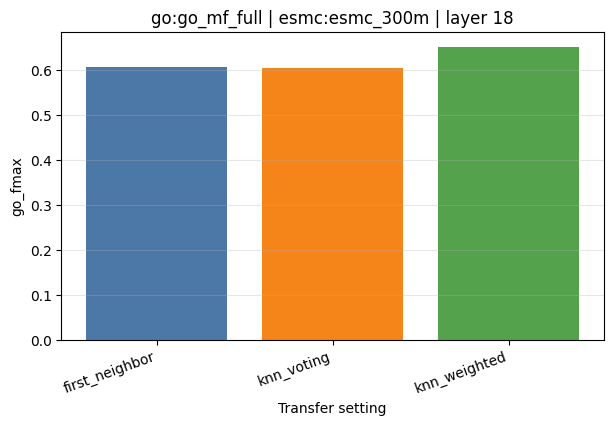

In [78]:
def choose_metric(results: pd.DataFrame, requested: str | None) -> str:
    if requested is not None:
        if requested not in results.columns:
            raise EmbeddingInputError(f"Requested metric {requested!r} is not present. Available: {list(results.columns)}")
        return requested
    preferred = ["go_fmax", "macro_f1", "micro_f1", "f1", "accuracy", "auroc", "auprc", "spearmanr", "r2", "rmse", "mae"]
    for metric in preferred:
        if metric in results.columns:
            return metric
    metric_columns = [
        column
        for column in results.columns
        if column not in {"transfer", "layer", "elapsed_seconds", "train_count", "val_count", "test_count"}
    ]
    if not metric_columns:
        raise EmbeddingInputError("No metric columns found in transfer-probe results.")
    return metric_columns[0]


#metric = choose_metric(variant_results, METRIC)
metric="go_fmax"
metric_direction = "lower is better" if metric in {"rmse", "mae"} else "higher is better"
print(f"Selected metric: {metric} ({metric_direction})")

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(variant_results["transfer"], variant_results[metric], color=["#4C78A8", "#F58518", "#54A24B"])
ax.set_xlabel("Transfer setting")
ax.set_ylabel(metric)
ax.set_title(f"{dataset_entry.id} | {MODEL_CLASS}:{MODEL_NAME} | layer {generated_layer_index}")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=20, ha="right")
plt.show()


## Next Steps

Use `neighbor_selection="cutoff_distance"` with `distance_cutoff` when you want transfer to reject remote training examples. For multilabel tasks, keep `threshold=None` when downstream metrics should choose thresholds from the score vectors.
